# Config

Max Fan Load Power: 33.60W


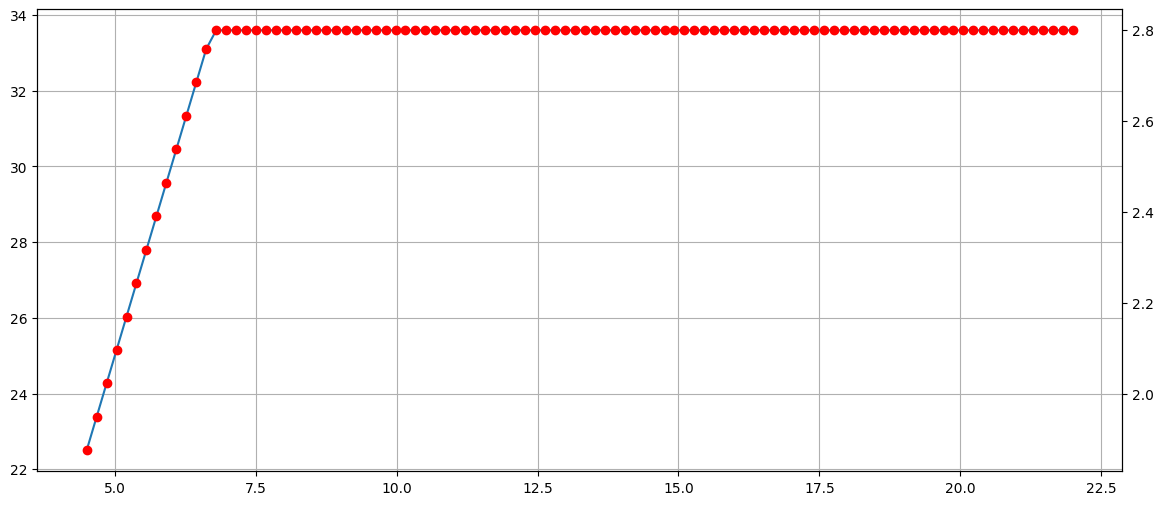

c_out r_esr: 18.34 mOhm


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 100)
i_in_max = 5 # USB-C PD max current
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

input_voltage_operating_points = v_in
input_current_operating_points_max = np.full_like(input_voltage_operating_points,i_in_nom_max)
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

L1 = 47e-6 # from 1_.pynb
c_out_chosen_nominal = 4.7e-3 * 4
c_out_chosen_derated = 4.7e-3 * 4 * 0.7 # 4 4700 uF with 70% dc bias derating
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_chosen_nominal)
print(f"c_out r_esr: {r_esr*1000:.2f} mOhm")

# feedback resistors

In [2]:
v_out = 12
r_fb1 = 20e3 # random choice, copy datasheet application. 1kOhm to 100kOhm typical
r_fb2 =  (v_out - 0.8 ) / 0.8 * r_fb1
print(f"r_fb2: {r_fb2/1000:.2f} kOhm")

r_fb2: 280.00 kOhm


# current sense resistor

In [3]:
r_sense_buck = 0.08 / max(i_out_operating_points)

i_l_max = v_out * max(i_out_operating_points) / (0.9 * min(input_voltage_operating_points))
i_l_peak = i_l_max + min(input_voltage_operating_points) * (v_out - min(input_voltage_operating_points)) / (2 * L1 * f_sw * v_out)


r_sense_buck = 0.08 / max(i_out_operating_points)
r_sense_boost = 0.12 / i_l_peak
print(f"r_sense_buck: {r_sense_buck*1000:.1f} mOhm")
print(f"r_sense_boost: {r_sense_boost*1000:.1f} mOhm")

# choose 12 mOhm 
r_sense = 0.012

p_r_sense_max = (0.120/r_sense) ** 2 * r_sense * (1 - min(input_voltage_operating_points) / v_out)
print(f"p_r_sense_max: {p_r_sense_max} W")

# use 2 watt power rating resistor


r_sense_buck: 28.6 mOhm
r_sense_boost: 14.0 mOhm
p_r_sense_max: 0.75 W


# slope compensation

c_slope calculated: 1.567 nF
c_slope chosen: 0.330 nF
v_comp_buck: 1.207 V
v_comp_boost: 2.145 V


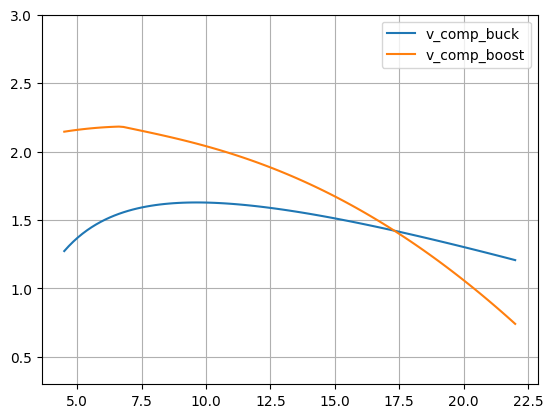

In [5]:
gm_slope = 2e-6  # datasheet
a_cs = 5  # datasheet
c_slope = gm_slope * L1 / (r_sense * a_cs)
print(f"c_slope calculated: {c_slope*1e9:.3f} nF")

c_slope = 0.33e-9 # choose smaller for noise immunity. check below if ok based on v_comp range
print(f"c_slope chosen: {c_slope*1e9:.3f} nF")

# need to check what value to use still. effect on noise immunity in buck boost transition and input output range
D_buck = v_out / input_voltage_operating_points
v_comp_buck = (
    1.6
    - a_cs * r_sense * v_out / (2 * L1 * f_sw) * (1 - D_buck)
    - (2e-6 * (input_voltage_operating_points - v_out) + 6e-6)
    / (c_slope * f_sw)
    * (1 - D_buck)
)
print(f"v_comp_buck: {v_comp_buck[-1]:.3f} V")

D_boost = 1 - input_voltage_operating_points / v_out
v_comp_boost = (
    1.6
    + a_cs
    * r_sense
    * (
        i_out_operating_points * v_out / input_voltage_operating_points
        + input_voltage_operating_points / (2 * L1 * f_sw) * D_boost
    )
    + (2e-6 * (v_out - input_voltage_operating_points) + 5e-6)
    / (c_slope * f_sw)
    * (1 - D_boost)
)

print(f"v_comp_boost: {v_comp_boost[0]:.3f} V")
plt.plot(input_voltage_operating_points, v_comp_buck, label = "v_comp_buck")
plt.plot(input_voltage_operating_points, v_comp_boost, label = "v_comp_boost")
plt.grid()
plt.ylim([0.3,3])
plt.legend()

# ok, since v_comp within 0.3V to 3V per datasheet

# UVLO

In [6]:
delta_i_hys_op = np.asarray([2.15e-6, 3.15e-6, 4.25e-6]) # datasheet
r_uv2 = 249e3 #
delta_v_hys_uv = delta_i_hys_op * r_uv2

print(delta_v_hys_uv)

i_en_stby = np.asarray([1e-6, 2e-6, 3e-6]) # datasheet
v_en_op = np.asarray([1.17, 1.22, 1.29]) # datasheet
r_uv1 = 100e3
v_in_uv = v_en_op * (1 + r_uv2 / r_uv1) -  r_uv2 * i_en_stby
print(v_in_uv) #rough range, just checking typical value ok for 5V usb with 500mV drop

[0.53535 0.78435 1.05825]
[3.8343 3.7598 3.7551]


# Dither capacitor

In [7]:
# not implemented, populated wiht 0 Ohm resistor to ground
f_mod = 500
c_dith = 10e-6 / (f_mod * 0.24)
print(f"{c_dith*1e9:0.1f} nF")

83.3 nF


# Mosfets (calculated in 2_.ipynb)

# Frequency Compensation

In [29]:
r_out = v_out / i_out_operating_points
f_p1_boost = 1 / 2 / np.pi * (2 / (r_out * c_out_chosen_derated))
f_z1 =  1 / 2 / np.pi * (2 / (r_esr * c_out_chosen_derated))
D_max_boost = 1 - min(input_voltage_operating_points) / v_out
f_rhp_boost = 1 / 2 / np.pi * (r_out * (1 - D_max_boost) ** 2) / L1

f_p1_buck = 1 / 2 / np.pi * (1 / (r_out * c_out_chosen_derated))

print(f"f_p1_boost: {min(f_p1_boost):.1f} to {max(f_p1_boost):.1f} Hz")

print(f"f_z1: {f_z1:.1f} Hz")
print(f"f_rhp_boost: {min(f_rhp_boost):.1f} to {max(f_rhp_boost):.1f} Hz")
print(f"f_p1_buck: {min(f_p1_buck):.1f} to {max(f_p1_buck):.1f} Hz")

f_bw = 11 # based on cout calculations. less than 1/10 of max commutation speed of about 160 Hz from the load waveform as sanity check. much lower than rhp so safe
f_zc = 7 # says to place 1.5 x boost pole, but later calculations say it should be much less than f_bw. maybe our f_bw being low is weird. also. f_z1 is quite low, not sure what that means

f_p1_boost: 3.8 to 5.6 Hz
f_z1: 1318.7 Hz
f_rhp_boost: 2040.8 to 3047.6 Hz
f_p1_buck: 1.9 to 2.8 Hz


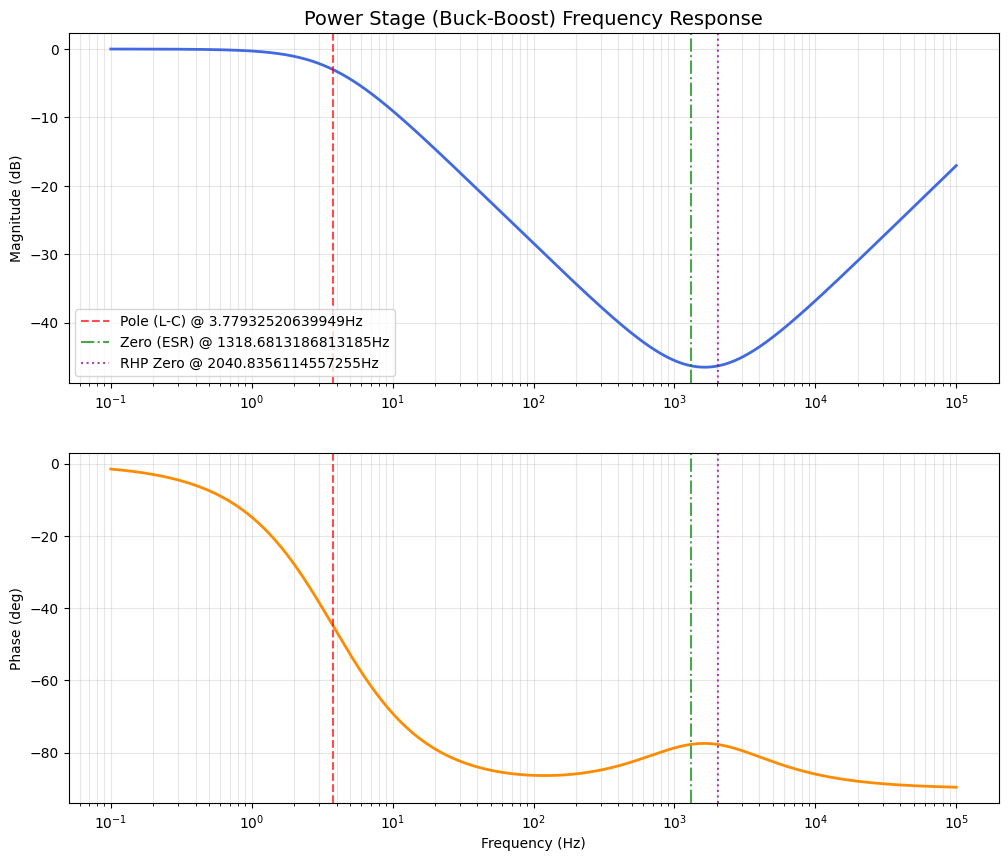

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. System Constants ---
gain_dc = 0 # dB need to calculate still?

# Convert to rad/s for transfer function
wp1 = 2 * np.pi * np.min(f_p1_boost)
wz1 = 2 * np.pi * f_z1
wrhp = 2 * np.pi * np.min(f_rhp_boost)

# Plant TF: G(s) = Gain * (1 + s/wz1) * (1 - s/wrhp) / (1 + s/wp1)
num = 10**(gain_dc/20) * np.polymul([1/wz1, 1], [-1/wrhp, 1])
den = [1/wp1, 1]
system = signal.TransferFunction(num, den)

# --- 2. Calculate Bode Data ---
# Custom frequency range to ensure we see the low-end pole
w_hz = np.logspace(-1, 5, 1000)
w, mag, phase = signal.bode(system, w=2*np.pi*w_hz)

# --- 3. Plotting ---
plt.figure(figsize=(12, 10))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(w_hz, mag, color='royalblue', linewidth=2)
plt.title('Power Stage (Buck-Boost) Frequency Response', fontsize=14)
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", alpha=0.3)

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(w_hz, phase, color='darkorange', linewidth=2)
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", alpha=0.3)

# --- 4. Annotations ---
features = {
    'Pole (L-C)': (wp1/2/np.pi, 'red', 'dashed'),
    'Zero (ESR)': (wz1/2/np.pi, 'green', 'dashdot'),
    'RHP Zero': (wrhp/2/np.pi, 'purple', 'dotted')
}

for label, (freq, color, style) in features.items():
    # Add vertical lines to both plots
    for ax in [1, 2]:
        plt.subplot(2, 1, ax)
        plt.axvline(freq, color=color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
    
    # Add text label to Magnitude plot
    plt.subplot(2, 1, 1)
plt.legend()

R_fb2: 280.0 kOhm
Rc: 100.0 kOhm
Cc: 0.227 uF
Chf: 159.15 nF


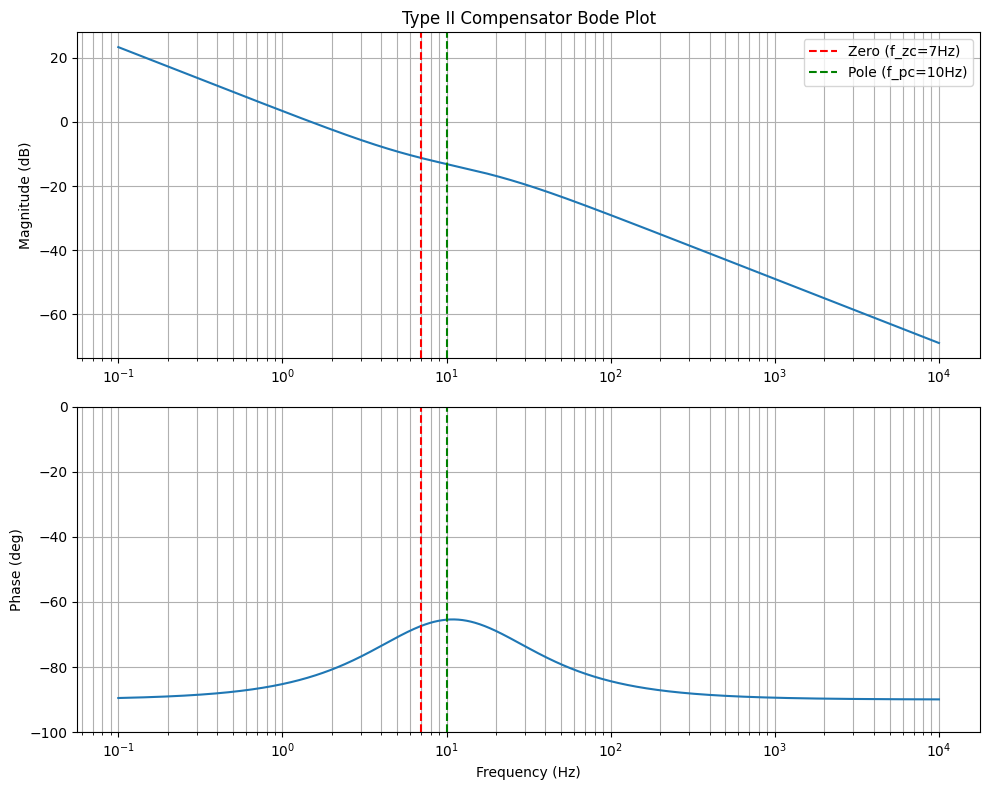

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Corrected variable names
v_out = 12
r_fb1 = 20e3
r_fb2 = (v_out - 0.8) / 0.8 * r_fb1 # 280k
v_ref = 0.8

# Frequencies
f_pc = 10     # High frequency pole, 7 to 10x bw

# Design values for components
Rc = 100e3       # Chosen component for example
Cc = 1 / (2 * np.pi * Rc * f_zc)
Chf = 1 / (2 * np.pi * Rc * f_pc)

# Transfer Function for Type II Op-Amp Compensator:
# H(s) = (1 + s*Rc*Cc) / (s*r_fb2*(Cc + Chf) * (1 + s*Rc*Cc*Chf/(Cc+Chf)))

num = [Rc * Cc, 1]
# Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
den = [r_fb2 * Rc * Cc * Chf, r_fb2 * (Cc + Chf), 0]

sys_comp = signal.TransferFunction(num, den)

# Frequencies for plot: 0.1 Hz to 10 kHz
w_hz = np.logspace(-1, 4, 1000)
w = 2 * np.pi * w_hz
w, mag, phase = signal.bode(sys_comp, w)

plt.figure(figsize=(10, 8))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(w_hz, mag)
plt.title('Type II Compensator Bode Plot')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both")
plt.axvline(f_zc, color='r', linestyle='--', label=f'Zero (f_zc={f_zc}Hz)')
plt.axvline(f_pc, color='g', linestyle='--', label=f'Pole (f_pc={f_pc}Hz)')
plt.legend()

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(w_hz, phase)
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.ylim(-100, 0)
plt.grid(True, which="both")
plt.axvline(f_zc, color='r', linestyle='--')
plt.axvline(f_pc, color='g', linestyle='--')

plt.tight_layout()
plt.savefig('compensator_bode_plot.png')

print(f"R_fb2: {r_fb2/1000:.1f} kOhm")
print(f"Rc: {Rc/1000:.1f} kOhm")
print(f"Cc: {Cc*1e6:.3f} uF")
print(f"Chf: {Chf*1e9:.2f} nF")

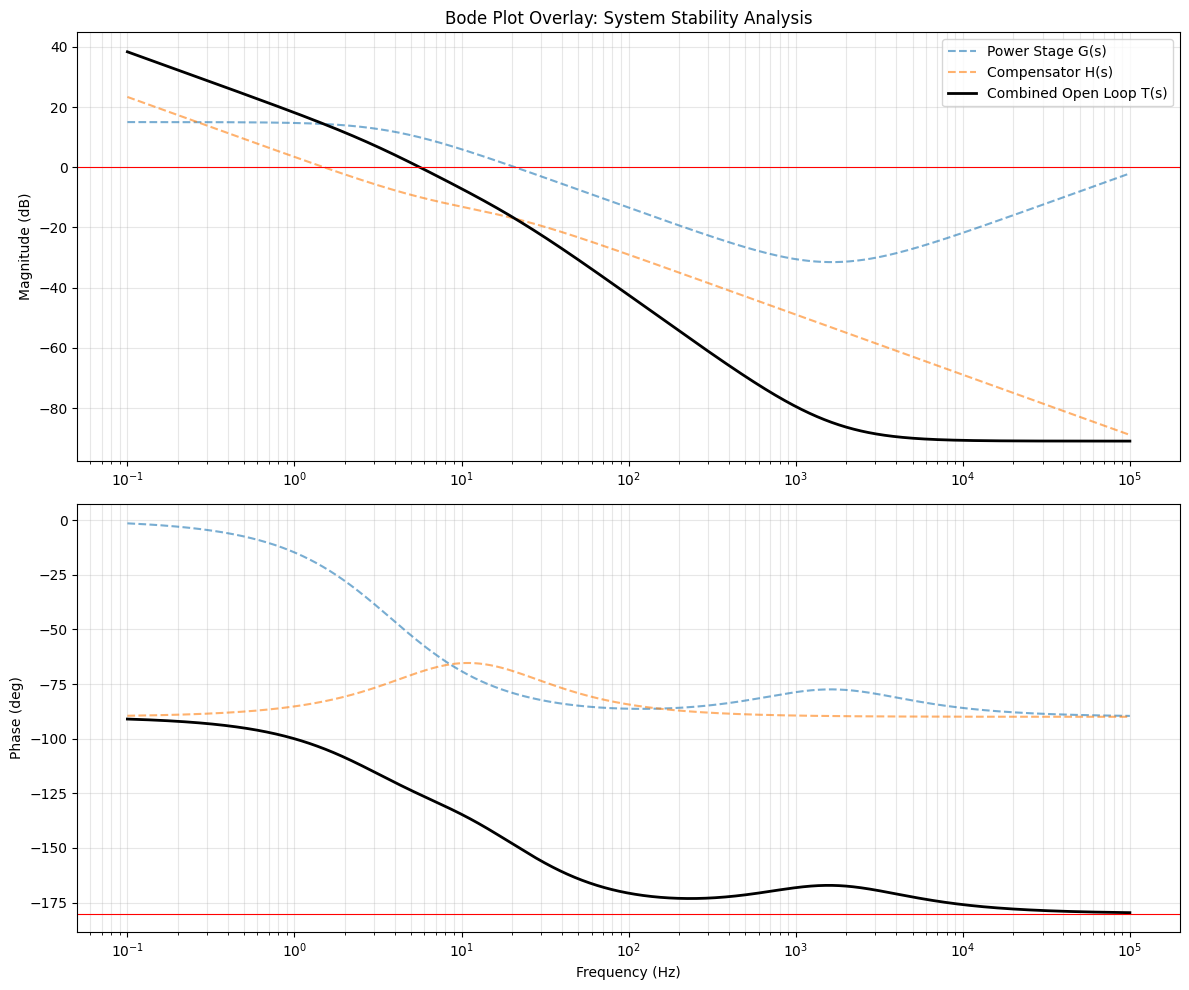

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- System Parameters ---
# Power Stage
fp1_ps = np.min(f_p1_boost)      # Dominant pole
fz1_ps = f_z1    # ESR Zero
frhp_ps = np.min(f_rhp_boost) # RHP Zero
gain_dc_ps = 15   # Estimated DC Gain in dB for visualization

# Compensator (Type II)
Rfb2 = 280e3      # From your previous calculation
Rc = 100e3
Cc = 1 / (2 * np.pi * Rc * f_zc)
Chf = 1 / (2 * np.pi * Rc * f_pc)

# --- Define Transfer Functions ---
# 1. Power Stage G(s)
# G(s) = K * (1 + s/wz1) * (1 - s/wrhp) / (1 + s/wp1)
wz1_ps = 2 * np.pi * fz1_ps
wrhp_ps = 2 * np.pi * frhp_ps
wp1_ps = 2 * np.pi * fp1_ps
num_ps = np.polymul([1/wz1_ps, 1], [-1/wrhp_ps, 1])
den_ps = [1/wp1_ps, 1]
sys_ps = signal.TransferFunction(10**(gain_dc_ps/20) * num_ps, den_ps)

# 2. Compensator H(s)
num_h = [Rc * Cc, 1]
den_h = [Rfb2 * Rc * Cc * Chf, Rfb2 * (Cc + Chf), 0]
sys_comp = signal.TransferFunction(num_h, den_h)

# 3. Open Loop T(s) = G(s) * H(s)
# Combine by multiplying transfer functions
num_total = np.polymul(sys_ps.num, sys_comp.num)
den_total = np.polymul(sys_ps.den, sys_comp.den)
sys_total = signal.TransferFunction(num_total, den_total)

# --- Plotting ---
w_hz = np.logspace(-1, 5, 1500)
w = 2 * np.pi * w_hz

_, mag_ps, phase_ps = signal.bode(sys_ps, w)
_, mag_comp, phase_comp = signal.bode(sys_comp, w)
_, mag_total, phase_total = signal.bode(sys_total, w)

plt.figure(figsize=(12, 10))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(w_hz, mag_ps, label='Power Stage G(s)', alpha=0.6, linestyle='--')
plt.semilogx(w_hz, mag_comp, label='Compensator H(s)', alpha=0.6, linestyle='--')
plt.semilogx(w_hz, mag_total, label='Combined Open Loop T(s)', linewidth=2, color='black')
plt.axhline(0, color='red', linewidth=0.8, linestyle='-') # 0dB line
plt.title('Bode Plot Overlay: System Stability Analysis')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(w_hz, phase_ps, alpha=0.6, linestyle='--')
plt.semilogx(w_hz, phase_comp, alpha=0.6, linestyle='--')
plt.semilogx(w_hz, phase_total, linewidth=2, color='black')
plt.axhline(-180, color='red', linewidth=0.8, linestyle='-') # -180 deg line
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig('combined_bode.png')